In [ ]:
# --- project bootstrap ---
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
os.chdir(ROOT)
# -------------------------


# Entropy contour GIF

Load cached Markov circuit data and render an entropy contour GIF over all cycles for one trajectory using Matplotlib animation.

In [1]:
# CPU control: run this cell before importing numpy/scipy
CPU_CAP = 20  # <-- set your desired CPU count here

import os
for _k in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_k] = str(CPU_CAP)

try:
    os.sched_setaffinity(0, set(range(90, 90+CPU_CAP)))
    print(f"CPU affinity set to {CPU_CAP} cores")
except (AttributeError, PermissionError) as _e:
    print(f"CPU affinity not set: {_e}")


CPU affinity set to 20 cores


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

DATA_PATH = (
    'cache/G_history_samples/'
    'N12x31/N12x31_C50_S250_nshNone_DW1_init-maxmix_n_a0.5_seq-random_exclNone_pm1.00_tbtf1_tbtflm0_markov_circuit_entropy_boundary_timeseries.npz'
)
OUT_GIF = 'figs/entropy_contour_traj0.gif'
TRAJ_IDX = 0
FPS = 5
Nx, Ny = 12, 31

In [ ]:
with np.load(DATA_PATH) as data:
    if 'G_hist' not in data:
        raise KeyError('G_hist not found in dataset')
    G_hist = data['G_hist']

S, T, N, N2 = G_hist.shape
assert N == N2
assert N == 2 * Nx * Ny, f'Expected N={2*Nx*Ny}, got {N}'

print(f'Samples={S}, Cycles={T-1 if T>0 else T}, N={N}')

In [ ]:
def entanglement_contour_single(G, Nx, Ny):
    G = np.asarray(G, dtype=np.complex128)
    I = np.eye(G.shape[0], dtype=np.complex128)
    G2 = 0.5 * (I + G)
    evals, vecs = np.linalg.eigh(G2)
    evals = np.clip(np.real_if_close(evals), 1e-12, 1 - 1e-12)
    f_eigs = -(evals * np.log(evals) + (1.0 - evals) * np.log(1.0 - evals))
    diagF = np.einsum('ik,k,ik->i', vecs, f_eigs, vecs.conj(), optimize=True).real
    diagF = diagF.reshape(2, Nx, Ny, order='F')
    return diagF.sum(axis=0)

In [ ]:
os.makedirs(os.path.dirname(OUT_GIF), exist_ok=True)

# Initialize figure
s0 = entanglement_contour_single(G_hist[TRAJ_IDX, 0], Nx, Ny)
fig, ax = plt.subplots(figsize=(5.5, 4.0), dpi=140)
im = ax.imshow(s0, origin='lower', cmap='magma', aspect='auto')
cb = fig.colorbar(im, ax=ax, label='entropy contour')
ax.set_xlabel('y')
ax.set_ylabel('x')
title = ax.set_title(f'Entropy contour | traj={TRAJ_IDX}, t=0')

def update(t):
    s_map = entanglement_contour_single(G_hist[TRAJ_IDX, t], Nx, Ny)
    im.set_data(s_map)
    title.set_text(f'Entropy contour | traj={TRAJ_IDX}, t={t}')
    return im, title

ani = animation.FuncAnimation(fig, update, frames=range(T), blit=False)
writer = animation.PillowWriter(fps=FPS)
ani.save(OUT_GIF, writer=writer)
plt.close(fig)
print(f'Saved GIF: {OUT_GIF}')

In [ ]:
# Single-trajectory, small-system Markov entropy-boundary timeseries
# Tune these parameters as needed
Nx = 6
Ny = 8
cycles = 12
alpha_1, alpha_2 = 30, 1
p_meas = 1.0
init_mode = 'maxmix'
sequence = 'random'
top_triv_back_forth = True

from fgtn.classA_U1FGTN import classA_U1FGTN
from tqdm import tqdm

def entanglement_contour_single(G, Nx, Ny):
    G = np.asarray(G, dtype=np.complex128)
    I = np.eye(G.shape[0], dtype=np.complex128)
    G2 = 0.5 * (I + G)
    evals, vecs = np.linalg.eigh(G2)
    evals = np.clip(np.real_if_close(evals), 1e-12, 1 - 1e-12)
    f_eigs = -(evals * np.log(evals) + (1.0 - evals) * np.log(1.0 - evals))
    diagF = np.einsum('ik,k,ik->i', vecs, f_eigs, vecs.conj(), optimize=True).real
    diagF = diagF.reshape(2, Nx, Ny, order='F')
    return diagF.sum(axis=0)  # (Nx, Ny)

model = classA_U1FGTN(Nx, Ny, DW=True, alpha_1=alpha_1, alpha_2=alpha_2)
if not (hasattr(model, 'DW_loc') and len(model.DW_loc) >= 2):
    raise ValueError('DW_loc not set; need DW=True with valid alpha profile')
x0 = int(model.DW_loc[0]) % Nx
x1 = int(model.DW_loc[1]) % Nx
left_pair = [x0 % Nx, (x0 + 1) % Nx]
right_pair = [x1 % Nx, (x1 - 1) % Nx]

res = model.run_markov_circuit(
    G_history=True,
    cycles=cycles,
    samples=1,
    progress=True,
    init_mode=init_mode,
    save=False,
    p_meas=p_meas,
    parallelize_samples=False,
    n_jobs=1,
    sequence=sequence,
    top_triv_back_forth=top_triv_back_forth,
)

G_hist = res['G_hist'][0]  # (T, Nlayer, Nlayer)
T = G_hist.shape[0]
left_vals = np.zeros(T, dtype=float)
right_vals = np.zeros(T, dtype=float)

for t in tqdm(range(T), desc='cycles'):
    s_map = entanglement_contour_single(G_hist[t], Nx, Ny)
    left_vals[t] = np.sum(s_map[left_pair, :])
    right_vals[t] = np.sum(s_map[right_pair, :])

t_axis = np.arange(T, dtype=int)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.0), constrained_layout=True)
axes[0].plot(t_axis, left_vals, marker='o', label='left boundary')
axes[0].plot(t_axis, right_vals, marker='o', label='right boundary')
axes[0].set_xlabel('cycle')
axes[0].set_ylabel('integrated contour')
axes[0].set_title('Linear scale')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(t_axis, left_vals, marker='o', label='left boundary')
axes[1].plot(t_axis, right_vals, marker='o', label='right boundary')
axes[1].set_xlabel('cycle')
axes[1].set_yscale('log')
axes[1].set_ylabel('integrated contour (log)')
axes[1].set_title('Log scale')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()


In [ ]:
# Plot boundary entropy + x=2,6,10 integrated contours from cached history
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from fgtn.classA_U1FGTN import classA_U1FGTN
DATA_PATH = (
    'cache/G_history_samples/'
    'N12x31_C50_S100_nshNone_DW1_init-maxmix_n_a0.5_seq-random_exclNone_pm1.00_tbtf1_tbtflm0_markov_circuit_entropy_boundary_timeseries.npz'
)

with np.load(DATA_PATH) as data:
    G_hist = data['G_hist']

S, T, N, N2 = G_hist.shape
if N != N2:
    raise ValueError(f'G_hist should be square in last dims, got {N}x{N2}.')

Nx, Ny = 12, 31
if N != 2 * Nx * Ny:
    raise ValueError(f'Expected N={2*Nx*Ny} for Nx={Nx}, Ny={Ny}; got N={N}.')

def entanglement_contour_batch(Gtt_batch, Nx, Ny):
    arr = np.asarray(Gtt_batch, dtype=np.complex128)
    if arr.ndim != 3:
        raise ValueError(f'expected (B,N,N); got {arr.shape}')

    B, Nlayer, _ = arr.shape
    I = np.eye(Nlayer, dtype=np.complex128)
    G2 = 0.5 * (I + arr)
    evals, vecs = np.linalg.eigh(G2)
    evals = np.clip(np.real_if_close(evals), 1e-12, 1 - 1e-12)
    f_eigs = -(evals * np.log(evals) + (1.0 - evals) * np.log(1.0 - evals))
    diagF = np.einsum('bik,bk,bik->bi', vecs, f_eigs, vecs.conj(), optimize=True).real
    diagF = diagF.reshape(B, 2, Nx, Ny, order='F')
    return diagF.sum(axis=1)

def _stderr(arr, axis=0):
    n = arr.shape[axis]
    if n <= 1:
        return np.zeros(arr.shape[1-axis], dtype=float)
    return np.std(arr, axis=axis, ddof=1) / np.sqrt(n)

model = classA_U1FGTN(Nx, Ny, DW=True, alpha_1=30, alpha_2=1)
if not (hasattr(model, 'DW_loc') and len(model.DW_loc) >= 2):
    raise ValueError('DW_loc not set; need DW=True with valid alpha profile')
x0 = int(model.DW_loc[0]) % Nx
x1 = int(model.DW_loc[1]) % Nx
left_pair = [x0 % Nx, (x0 + 1) % Nx]
right_pair = [x1 % Nx, (x1 - 1) % Nx]

extra_xs = [2, 6, 10]

left_by_sample = np.zeros((S, T), dtype=float)
right_by_sample = np.zeros((S, T), dtype=float)
extra_by_sample = {x: np.zeros((S, T), dtype=float) for x in extra_xs}

for t_idx in tqdm(range(T), desc='cycles'):
    s_batch = entanglement_contour_batch(G_hist[:, t_idx], Nx, Ny)
    left_by_sample[:, t_idx] = np.sum(s_batch[:, left_pair, :], axis=(1, 2))
    right_by_sample[:, t_idx] = np.sum(s_batch[:, right_pair, :], axis=(1, 2))
    for x in extra_xs:
        extra_by_sample[x][:, t_idx] = np.sum(s_batch[:, x, :], axis=1)

left_avg = np.mean(left_by_sample, axis=0)
right_avg = np.mean(right_by_sample, axis=0)
left_stderr = _stderr(left_by_sample, axis=0)
right_stderr = _stderr(right_by_sample, axis=0)

extra_avg = {x: np.mean(extra_by_sample[x], axis=0) for x in extra_xs}
extra_stderr = {x: _stderr(extra_by_sample[x], axis=0) for x in extra_xs}

t_vals = np.arange(T, dtype=int)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)

axes[0].errorbar(t_vals, left_avg, yerr=left_stderr, marker='o', ms=3, lw=1.2, label='left boundary')
axes[0].errorbar(t_vals, right_avg, yerr=right_stderr, marker='o', ms=3, lw=1.2, label='right boundary')
for x in extra_xs:
    axes[0].errorbar(t_vals, extra_avg[x], yerr=extra_stderr[x], marker='o', ms=3, lw=1.0, label=f'x={x}')
axes[0].set_xlabel('cycle')
axes[0].set_ylabel('integrated contour')
axes[0].set_title('Linear scale')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].errorbar(t_vals, left_avg, yerr=left_stderr, marker='o', ms=3, lw=1.2, label='left boundary')
axes[1].errorbar(t_vals, right_avg, yerr=right_stderr, marker='o', ms=3, lw=1.2, label='right boundary')
for x in extra_xs:
    axes[1].errorbar(t_vals, extra_avg[x], yerr=extra_stderr[x], marker='o', ms=3, lw=1.0, label=f'x={x}')
axes[1].set_xlabel('cycle')
axes[1].set_yscale('log')
axes[1].set_ylabel('integrated contour (log)')
axes[1].set_title('Log scale')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.show()


In [ ]:
# Cell 1: initialization, flattened H construction, diagonalization, spectrum
import numpy as np
import matplotlib.pyplot as plt
from fgtn.classA_U1FGTN import classA_U1FGTN
# ---- Tunable inputs ----
Nx, Ny = 12, 31
nshell = None
dw_mode = True
alpha_1, alpha_2 = 30.0, 1.0
# Optional override: scalar or (Nx,Ny) array; keep None to use class DW profile
alpha_override = None
# ------------------------

def _sub_indices_from_ycut(nx, ny, y_cut):
    yA = np.arange(y_cut, ny)
    sub_indices = []
    for y in yA:
        base = 2 * nx * y
        for x in range(nx):
            sub_indices.append(base + 2 * x)
            sub_indices.append(base + 2 * x + 1)
    return np.asarray(sub_indices, dtype=int), yA

def _fit_line(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 3:
        return np.nan, np.nan, np.nan
    m, b = np.polyfit(x, y, 1)
    y_hat = m * x + b
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = np.nan if ss_tot == 0 else (1.0 - ss_res / ss_tot)
    return float(m), float(b), float(r2)

def _integrated_curves_for_cut_list(C_cov, model, nx, ny, y_cut_list):
    Ay_list = ny - y_cut_list
    Sx_vs_Ay = np.zeros((nx, len(y_cut_list)), dtype=float)
    for i, y_cut in enumerate(y_cut_list):
        sub_idx, yA = _sub_indices_from_ycut(nx, ny, int(y_cut))
        C_sub = C_cov[np.ix_(sub_idx, sub_idx)]
        s_map = model.entanglement_contour(C_sub, nx, len(yA))
        Sx_vs_Ay[:, i] = np.sum(s_map, axis=1)
    return Ay_list, Sx_vs_Ay

model = classA_U1FGTN(Nx, Ny, nshell=nshell, DW=dw_mode, alpha_1=alpha_1, alpha_2=alpha_2)
model.construct_OW_projectors(nshell=nshell, DW=dw_mode)

if alpha_override is not None:
    if np.isscalar(alpha_override):
        model.alpha_profile = float(alpha_override) * np.ones((Nx, Ny), dtype=np.complex128)
    else:
        alpha_arr = np.asarray(alpha_override, dtype=np.complex128)
        if alpha_arr.shape != (Nx, Ny):
            raise ValueError(f"alpha_override must be scalar or shape ({Nx},{Ny}), got {alpha_arr.shape}")
        model.alpha_profile = alpha_arr
    model.alpha = model.alpha_profile
    model.construct_OW_projectors(nshell=nshell, DW=True)

Nlayer = 2 * Nx * Ny
H = np.zeros((Nlayer, Nlayer), dtype=np.complex128)
for Rx in range(Nx):
    for Ry in range(Ny):
        P_Ap = model._proj_from_WF(model.WF_Ap, Rx, Ry)
        P_Bp = model._proj_from_WF(model.WF_Bp, Rx, Ry)
        P_Am = model._proj_from_WF(model.WF_Am, Rx, Ry)
        P_Bm = model._proj_from_WF(model.WF_Bm, Rx, Ry)
        H += (P_Ap + P_Bp) - (P_Am + P_Bm)

H = 0.5 * (H + H.conj().T)
evals, evecs = np.linalg.eigh(H)

# Occupied-subspace projector from all negative-energy states
occ_mask = evals < 0.0
if np.count_nonzero(occ_mask) == 0:
    idx_occ = np.argsort(evals)[: Nlayer // 2]
else:
    idx_occ = np.where(occ_mask)[0]
U_occ = evecs[:, idx_occ]
P_occ = U_occ @ U_occ.conj().T
G = P_occ.conj()
C = 2.0 * G - np.eye(Nlayer, dtype=np.complex128)

if not (hasattr(model, 'DW_loc') and len(model.DW_loc) >= 2):
    raise ValueError('DW_loc not set; need DW=True with valid alpha profile')
x0 = int(model.DW_loc[0]) % Nx
x1 = int(model.DW_loc[1]) % Nx
left_pair = [x0 % Nx]
right_pair = [x1 % Nx]

plt.figure(figsize=(7, 4))
plt.plot(evals, '.', ms=3)
plt.xlabel('eigenvalue index')
plt.ylabel('energy')
plt.title('Flattened Hamiltonian spectrum')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f'Nlayer={Nlayer}, occupied modes={len(idx_occ)}')
print(f'DW locations: x0={x0}, x1={x1}')


SyntaxError: invalid syntax (29121337.py, line 7)

In [ ]:
# Cell 2: half-system contour heatmap + contour-vs-y cuts + integrated contour vs subsystem size (all x)
y_cut_half = Ny // 2
sub_idx_half, yA_half = _sub_indices_from_ycut(Nx, Ny, y_cut_half)
C_sub_half = C[np.ix_(sub_idx_half, sub_idx_half)]
s_half = model.entanglement_contour(C_sub_half, Nx, len(yA_half))  # shape (Nx, Ny_half)

y_cut_list_full = np.arange(2, Ny - 2, dtype=int)
Ay_list_full, Sx_vs_Ay_full = _integrated_curves_for_cut_list(C, model, Nx, Ny, y_cut_list_full)

fig, axes = plt.subplots(1, 3, figsize=(19, 4.8), constrained_layout=True)

# (1) Heatmap
im = axes[0].imshow(s_half.T, origin='lower', aspect='auto', cmap='magma')
axes[0].set_title(f'Half-system contour (y >= {y_cut_half})')
axes[0].set_xlabel('x')
axes[0].set_ylabel('subsystem y index')
fig.colorbar(im, ax=axes[0], label='s(x,y)')

# (2) Entanglement contour vs y for varying x (gradient color by x)
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=0, vmax=max(Nx - 1, 1))
for x in range(Nx):
    axes[1].plot(yA_half, s_half[x, :], lw=1.4, color=cmap(norm(x)))
axes[1].set_title('Contour cuts vs y (varying x)')
axes[1].set_xlabel('global y')
axes[1].set_ylabel('s(x,y)')
axes[1].grid(alpha=0.25)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes[1], label='x')

# (3) Integrated contour vs |A_y| for all x
for x in range(Nx):
    axes[2].plot(Ay_list_full, Sx_vs_Ay_full[x], lw=1.2, alpha=0.7, color=cmap(norm(x)))
axes[2].set_title('Integrated contour vs |A_y| (all x)')
axes[2].set_xlabel('|A_y| = Ny - y_cut')
axes[2].set_ylabel('sum_y s(x,y)')
axes[2].grid(alpha=0.25)

plt.show()


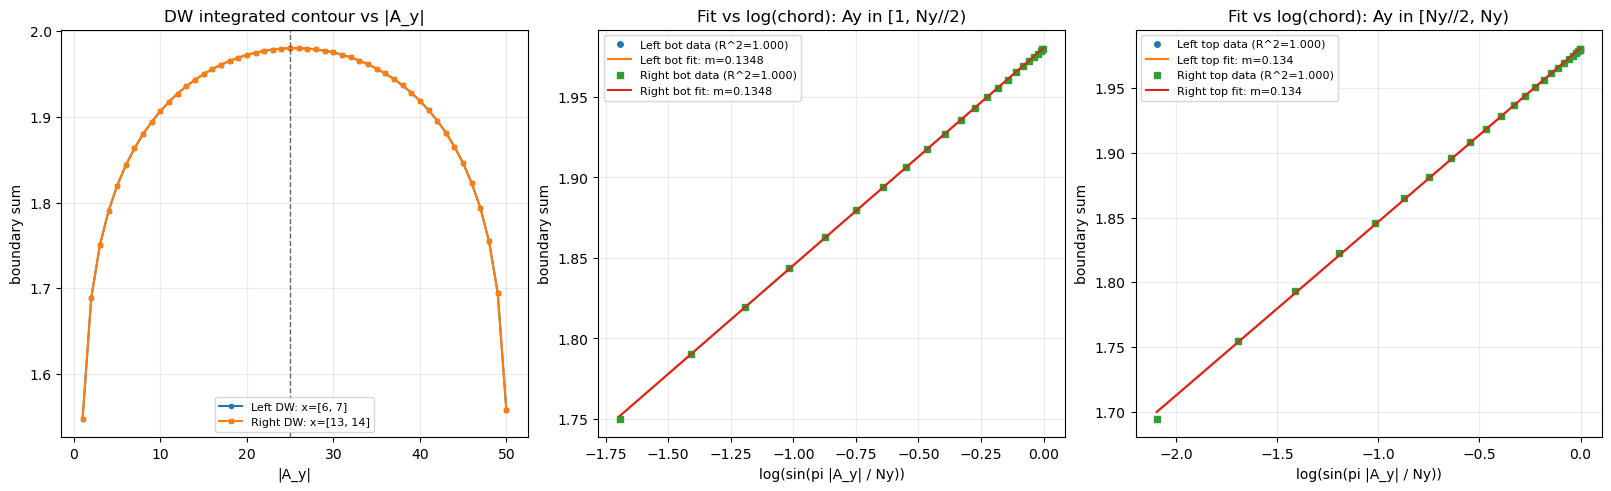

1) Left DW,  Ay in [1, Ny//2):   slope=0.134829, intercept=1.98023, R^2=0.999952
2) Left DW,  Ay in [Ny//2, Ny):  slope=0.134009, intercept=1.98079, R^2=0.999698
3) Right DW, Ay in [1, Ny//2):   slope=0.134829, intercept=1.98023, R^2=0.999952
4) Right DW, Ay in [Ny//2, Ny):  slope=0.134009, intercept=1.98079, R^2=0.999698


In [ ]:
# Cell 3: four DW fit configs split by Ay range
Ay_all = np.arange(1, Ny, dtype=int)
y_cut_all = Ny - Ay_all

Ay_all, Sx_vs_Ay = _integrated_curves_for_cut_list(C, model, Nx, Ny, y_cut_all)
left_curve = Sx_vs_Ay[left_pair[0]] + Sx_vs_Ay[left_pair[1]]
right_curve = Sx_vs_Ay[right_pair[0]] + Sx_vs_Ay[right_pair[1]]

# Split ranges:
# 1) [1, Ny//2)
# 2) [Ny//2, Ny)
mask_bot = (Ay_all > 2) & (Ay_all <= Ny // 2)
mask_top = (Ay_all >= Ny // 2) & (Ay_all < Ny-1)

Ay_bot = Ay_all[mask_bot]
Ay_top = Ay_all[mask_top]

left_bot = left_curve[mask_bot]
left_top = left_curve[mask_top]
right_bot = right_curve[mask_bot]
right_top = right_curve[mask_top]

x_bot = np.log(np.sin(np.pi * Ay_bot / Ny))
x_top = np.log(np.sin(np.pi * Ay_top / Ny))

mLB, bLB, r2LB = _fit_line(x_bot, left_bot)    # left, bottom
mLT, bLT, r2LT = _fit_line(x_top, left_top)    # left, top
mRB, bRB, r2RB = _fit_line(x_bot, right_bot)   # right, bottom
mRT, bRT, r2RT = _fit_line(x_top, right_top)   # right, top

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

# Raw integrated curves
axes[0].plot(Ay_all, left_curve, 'o-', ms=3, label=f'Left DW: x={left_pair}')
axes[0].plot(Ay_all, right_curve, 's-', ms=3, label=f'Right DW: x={right_pair}')
axes[0].axvline(Ny // 2, color='k', ls='--', lw=1, alpha=0.6)
axes[0].set_title('DW integrated contour vs |A_y|')
axes[0].set_xlabel('|A_y|')
axes[0].set_ylabel('boundary sum')
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

# Bottom-half fits: Ay in [1, Ny//2)
axes[1].plot(x_bot, left_bot, 'o', ms=4, label=f'Left bot data (R^2={r2LB:.3f})')
axes[1].plot(x_bot, mLB * x_bot + bLB, '-', lw=1.5, label=f'Left bot fit: m={mLB:.4g}')
axes[1].plot(x_bot, right_bot, 's', ms=4, label=f'Right bot data (R^2={r2RB:.3f})')
axes[1].plot(x_bot, mRB * x_bot + bRB, '-', lw=1.5, label=f'Right bot fit: m={mRB:.4g}')
axes[1].set_title('Fit vs log(chord): Ay in [1, Ny//2)')
axes[1].set_xlabel('log(sin(pi |A_y| / Ny))')
axes[1].set_ylabel('boundary sum')
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

# Top-half fits: Ay in [Ny//2, Ny)
axes[2].plot(x_top, left_top, 'o', ms=4, label=f'Left top data (R^2={r2LT:.3f})')
axes[2].plot(x_top, mLT * x_top + bLT, '-', lw=1.5, label=f'Left top fit: m={mLT:.4g}')
axes[2].plot(x_top, right_top, 's', ms=4, label=f'Right top data (R^2={r2RT:.3f})')
axes[2].plot(x_top, mRT * x_top + bRT, '-', lw=1.5, label=f'Right top fit: m={mRT:.4g}')
axes[2].set_title('Fit vs log(chord): Ay in [Ny//2, Ny)')
axes[2].set_xlabel('log(sin(pi |A_y| / Ny))')
axes[2].set_ylabel('boundary sum')
axes[2].grid(alpha=0.25)
axes[2].legend(fontsize=8)

plt.show()

print(f'1) Left DW,  Ay in [1, Ny//2):   slope={mLB:.6g}, intercept={bLB:.6g}, R^2={r2LB:.6g}')
print(f'2) Left DW,  Ay in [Ny//2, Ny):  slope={mLT:.6g}, intercept={bLT:.6g}, R^2={r2LT:.6g}')
print(f'3) Right DW, Ay in [1, Ny//2):   slope={mRB:.6g}, intercept={bRB:.6g}, R^2={r2RB:.6g}')
print(f'4) Right DW, Ay in [Ny//2, Ny):  slope={mRT:.6g}, intercept={bRT:.6g}, R^2={r2RT:.6g}')


In [ ]:
# Current-density maps from sample-averaged final state (postselected Ny=36 run)
import numpy as np
import matplotlib.pyplot as plt
from fgtn.classA_U1FGTN import classA_U1FGTN
DATA_PATH = (
    'cache/G_history_samples/'
    'N12x36_C5_S250_nshNone_DW1_init-default_n_a0.5_seq-random_exclNone_pm1.00_tbtf1_tbtflm0_ps1_markov_circuit_final_size_sweep_postselect.npz'
)

Nx, Ny = 12, 36
alpha_1, alpha_2 = 30, 1

with np.load(DATA_PATH) as data:
    if 'G_final' not in data:
        raise KeyError(f"'G_final' not found in {DATA_PATH}; found keys={list(data.keys())}")
    G_final = data['G_final']  # (S, Nlayer, Nlayer)

if G_final.ndim != 3:
    raise ValueError(f'Expected G_final shape (S,N,N); got {G_final.shape}')
S, N, N2 = G_final.shape
if N != N2:
    raise ValueError(f'G_final matrices must be square; got {N}x{N2}')
if N != 2 * Nx * Ny:
    raise ValueError(f'Expected N={2*Nx*Ny}; got N={N}. Check Nx/Ny or dataset path.')

G_avg = np.mean(G_final, axis=0)

model = classA_U1FGTN(Nx, Ny, nshell=None, DW=True, alpha_1=alpha_1, alpha_2=alpha_2)
J_x, J_y = model.current_maps_gauge_invariant(G_avg, Nx=Nx, Ny=Ny)

fig, axes = model.plot_current_maps(J_x, J_y, figsize=(18, 5), cmap='RdBu_r', quiver_cmap='plasma')
fig.suptitle(f'Sample-avg current density from G_final (S={S})', y=1.02)
plt.show()

print(f'Loaded {S} samples from: {DATA_PATH}')
print(f'Computed J_x, J_y with shapes: {J_x.shape}, {J_y.shape}')


DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------


Sample 1 | Markov RAC (DW boundary sweep):   0%|          | 0/3840 [00:00<?, ?site/s]

Observables (samples):   0%|          | 0/1 [00:00<?, ?it/s]

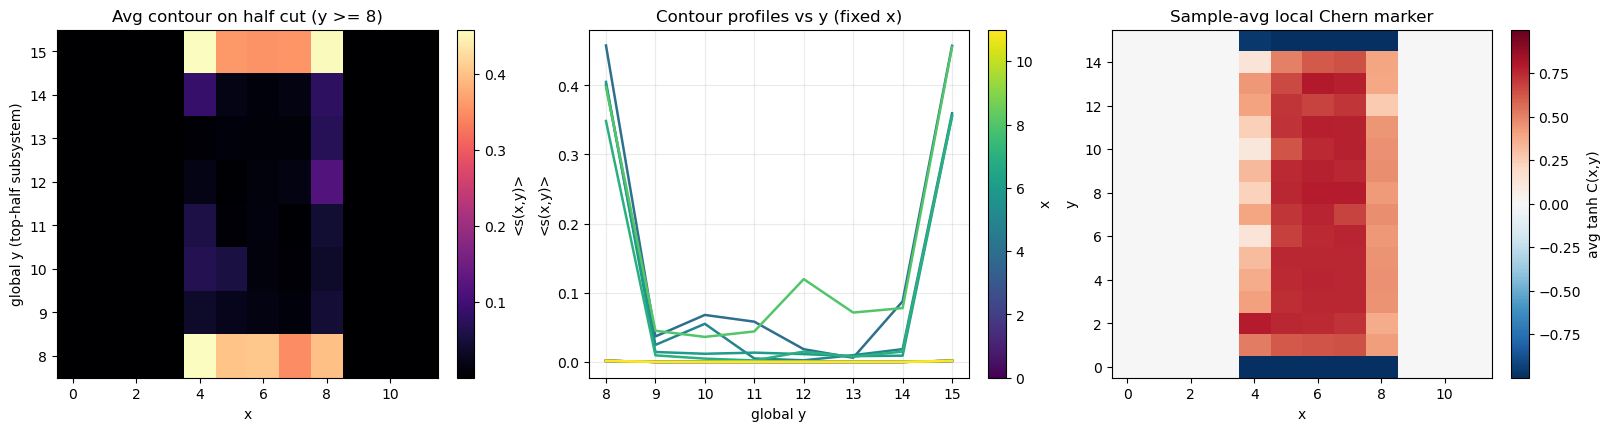

In [ ]:
# Markov small-system: sample-averaged half-cut entanglement contour
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from tqdm.auto import tqdm
import importlib
import fgtn.classA_U1FGTN as classA_mod
importlib.reload(classA_mod)
from fgtn.classA_U1FGTN import classA_U1FGTN
# --- parameters ---
Nx, Ny = 12, 16
cycles = 20
samples = 1
alpha_1, alpha_2 = 30, 1
p_meas = 1.0
sequence = "random"

model = classA_U1FGTN(Nx, Ny, DW=True, alpha_1=alpha_1, alpha_2=alpha_2)
res = model.run_markov_circuit(
    G_history=False,
    progress=True,
    cycles=cycles,
    samples=samples,
    parallelize_samples=False,
    init_mode="default",
    save=False,
    p_meas=p_meas,
    sequence=sequence,
    top_triv_back_forth=False
)

G_final = np.asarray(res["G_final"], dtype=np.complex128)  # (S, Nlayer, Nlayer)
S = G_final.shape[0]

y_cut = Ny // 2
yA = np.arange(y_cut, Ny, dtype=int)
Ny_sub = len(yA)

# Flattened top-layer index: i = mu + 2*x + 2*Nx*y
sub_indices = []
for y in yA:
    base = 2 * Nx * y
    for x in range(Nx):
        sub_indices.append(base + 2 * x)
        sub_indices.append(base + 2 * x + 1)
sub_indices = np.array(sub_indices, dtype=int)

s_maps = np.zeros((S, Nx, Ny_sub), dtype=float)
chern_maps = np.zeros((S, Nx, Ny), dtype=float)
for s in tqdm(range(S), desc="Observables (samples)", leave=True):
    Gs = G_final[s]
    G_sub = Gs[np.ix_(sub_indices, sub_indices)]
    s_maps[s] = model.entanglement_contour(G_sub, Nx, Ny_sub)
    chern_maps[s] = np.real(model.local_chern_marker_flat(Gs))

s_map_avg = np.mean(s_maps, axis=0)
chern_avg = np.mean(chern_maps, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)

im0 = axes[0].imshow(
    s_map_avg.T,
    origin="lower",
    aspect="auto",
    cmap="magma",
    extent=(-0.5, Nx - 0.5, yA[0] - 0.5, yA[-1] + 0.5),
)
axes[0].set_xlabel("x")
axes[0].set_ylabel("global y (top-half subsystem)")
axes[0].set_title(f"Avg contour on half cut (y >= {y_cut})")
fig.colorbar(im0, ax=axes[0], label="<s(x,y)>")

cmap = cm.viridis
norm = colors.Normalize(vmin=0, vmax=Nx - 1)
for x in range(Nx):
    axes[1].plot(yA, s_map_avg[x], color=cmap(norm(x)), lw=1.8)
axes[1].set_xlabel("global y")
axes[1].set_ylabel("<s(x,y)>")
axes[1].set_title("Contour profiles vs y (fixed x)")
axes[1].grid(alpha=0.25)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=axes[1], label="x")

chern_v = float(np.max(np.abs(chern_avg)))
if chern_v <= 0:
    chern_v = 1.0
im2 = axes[2].imshow(
    chern_avg.T,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r",
    vmin=-chern_v,
    vmax=chern_v,
)
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_title("Sample-avg local Chern marker")
fig.colorbar(im2, ax=axes[2], label="avg tanh C(x,y)")

plt.show()
